## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print("TensorFlow", tf.__version__, "| GPU:", gpus)


TensorFlow 2.10.1 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("TensorFlow version:", tf.__version__)

# Cố định random seed để chạy lại cho kết quả giống nhau
SEED = 42
tf.keras.utils.set_random_seed(SEED)

TensorFlow version: 2.10.1


## 2. Loading and explore the dataset

Categories: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


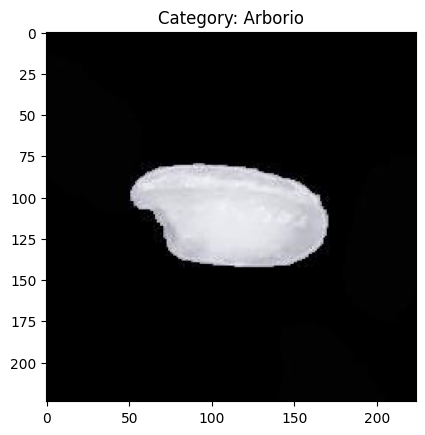

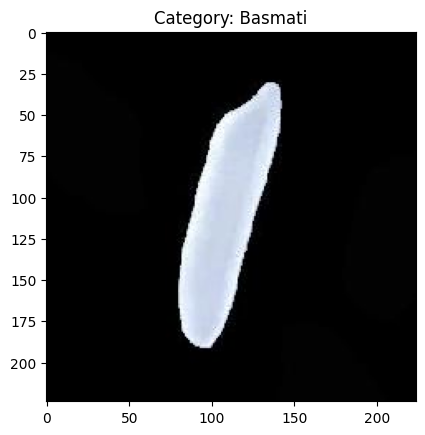

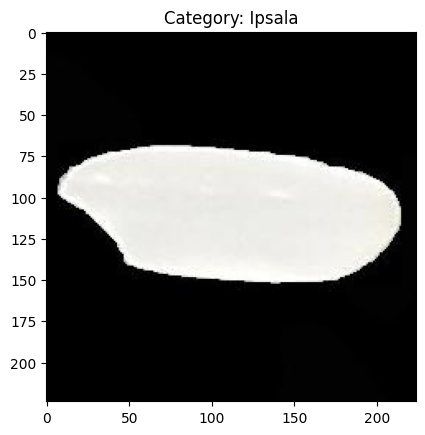

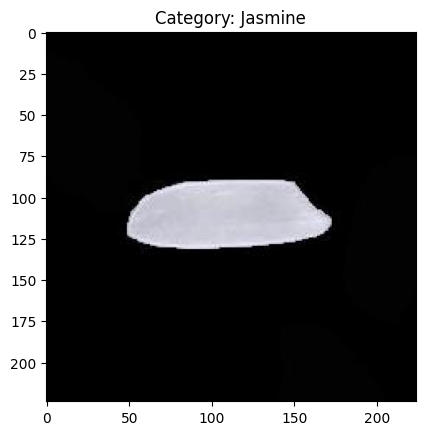

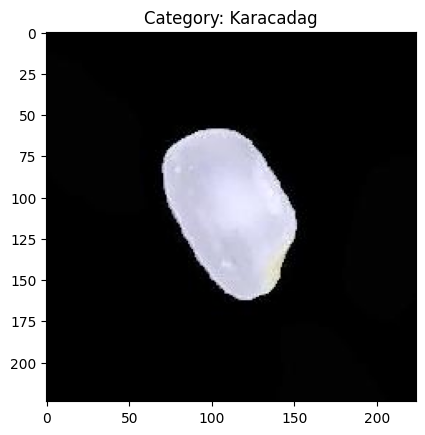

In [3]:
import os
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Define the dataset path
dataset_path = r"D:\Rice_DL_Project\Rice_Classification\data\raw\Rice_Image_Dataset"  

# Explore the dataset
categories = [category for category in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, category))]
print("Categories:", categories)

# Visualize some sample images from each category
for category in categories:
    category_path = os.path.join(dataset_path, category)
    sample_image = os.listdir(category_path)[0]  # Pick one image from each category
    img = image.load_img(os.path.join(category_path, sample_image), target_size=(224, 224))
    plt.imshow(img)
    plt.title(f"Category: {category}")
    plt.show()

### Data quality check

Check class balance, corrupt files, image size/mode and duplicate files (MD5). Duplicates are removed before splitting to avoid train/test leakage.

In [4]:
from PIL import Image
import hashlib

rows = []
for category in sorted(categories):
    folder = os.path.join(dataset_path, category)
    for fname in sorted(os.listdir(folder)):
        path = os.path.join(folder, fname)
        try:
            with Image.open(path) as im:
                im.verify()                      # detect corrupt files
            with Image.open(path) as im:
                size, mode = im.size, im.mode
            with open(path, "rb") as f:
                md5 = hashlib.md5(f.read()).hexdigest()
            rows.append((path, category, size, mode, md5))
        except Exception as e:
            print("Corrupt:", path, e)

info = pd.DataFrame(rows, columns=["filepath", "label", "size", "mode", "md5"])
print("Images per class:\n", info["label"].value_counts(), "\n")
print("Image sizes:\n", info["size"].value_counts(), "\n")
print("Color modes:\n", info["mode"].value_counts(), "\n")
print("Duplicate files:", info["md5"].duplicated().sum())
print("Duplicate groups with conflicting labels:", (info.groupby("md5")["label"].nunique() > 1).sum())

# Drop conflicting-label groups, then keep one copy of each duplicate
conflict = info.groupby("md5")["label"].transform("nunique") > 1
clean_df = info[~conflict].drop_duplicates("md5").reset_index(drop=True)
print(f"Kept {len(clean_df)} of {len(info)} images")

Images per class:
 label
Arborio      15000
Basmati      15000
Ipsala       15000
Jasmine      15000
Karacadag    15000
Name: count, dtype: int64 

Image sizes:
 size
(250, 250)    75000
Name: count, dtype: int64 

Color modes:
 mode
RGB    75000
Name: count, dtype: int64 

Duplicate files: 297
Duplicate groups with conflicting labels: 0
Kept 74703 of 75000 images


## 3. Data Preprocessing

Split 70/15/15 (stratified by class). Val/test are not shuffled so predictions stay aligned with labels.
Random seed được cố định bằng `SEED` (split và generator).

In [5]:
# Use the cleaned (filepath, label) table from the data quality check
df = clean_df[["filepath", "label"]]

# Split 70% train, 15% validation, 15% test
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

datagen = ImageDataGenerator(rescale=1./255)

def make_generator(data, shuffle):
    return datagen.flow_from_dataframe(
        data,
        x_col="filepath",
        y_col="label",
        target_size=(224, 224),
        batch_size=32,
        class_mode="categorical",
        shuffle=shuffle,
        seed=SEED,
    )

train_generator = make_generator(train_df, shuffle=True)
validation_generator = make_generator(val_df, shuffle=False)
test_generator = make_generator(test_df, shuffle=False)

Train: 52292 | Val: 11205 | Test: 11206
Found 52292 validated image filenames belonging to 5 classes.
Found 11205 validated image filenames belonging to 5 classes.
Found 11206 validated image filenames belonging to 5 classes.


## 4. CNN model

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# Initialize the CNN model
model = Sequential()

# Input layer (added explicitly)
model.add(Input(shape=(224, 224, 3)))

# First convolutional layer
model.add(Conv2D(32, (3, 3), activation='relu'))  
model.add(MaxPooling2D(pool_size=(2, 2)))  

# Second convolutional layer
model.add(Conv2D(64, (3, 3), activation='relu'))  
model.add(MaxPooling2D(pool_size=(2, 2)))  

# Third convolutional layer
model.add(Conv2D(128, (3, 3), activation='relu')) 
model.add(MaxPooling2D(pool_size=(2, 2)))  

# Flatten the 2D feature maps into 1D
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))

# Add a Dropout layer to prevent overfitting
model.add(Dropout(0.5))

# Output layer (5 classes for classification)
model.add(Dense(5, activation='softmax'))

## 5. Compiling the CNN Model

In [7]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 26, 26, 128)      0

## 6. Model Training

Train once and save to disk. If a saved model exists it is loaded instead of retraining (set `FORCE_RETRAIN = True` to retrain).

In [8]:
import json
import time

FORCE_RETRAIN = False
models_dir = r"D:\Rice_DL_Project\Rice_Classification\models"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "model1_cnn.h5")
history_path = os.path.join(models_dir, "model1_cnn_history.json")
time_path = os.path.join(models_dir, "model1_cnn_time.json")

if os.path.exists(model_path) and os.path.exists(history_path) and not FORCE_RETRAIN:
    # Reuse the saved model and its training history
    model = tf.keras.models.load_model(model_path, compile=False)
    with open(history_path) as f:
        history_dict = json.load(f)
    print("Loaded saved model:", model_path)
else:
    start = time.time()
    history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator,
    )
    train_sec = time.time() - start
    history_dict = history.history
    model.save(model_path, include_optimizer=False)
    with open(history_path, "w") as f:
        json.dump(history_dict, f)
    with open(time_path, "w") as f:
        json.dump({"train_time_sec": train_sec}, f)
    print("Trained and saved model to:", model_path)

print("Epochs:", len(history_dict["loss"]))
print("Final epoch:", {k: round(v[-1], 4) for k, v in history_dict.items()})

Loaded saved model: D:\Rice_DL_Project\Rice_Classification\models\model1_cnn.h5
Epochs: 10
Final epoch: {'loss': 0.0135, 'accuracy': 0.9958, 'val_loss': 0.0213, 'val_accuracy': 0.9946}


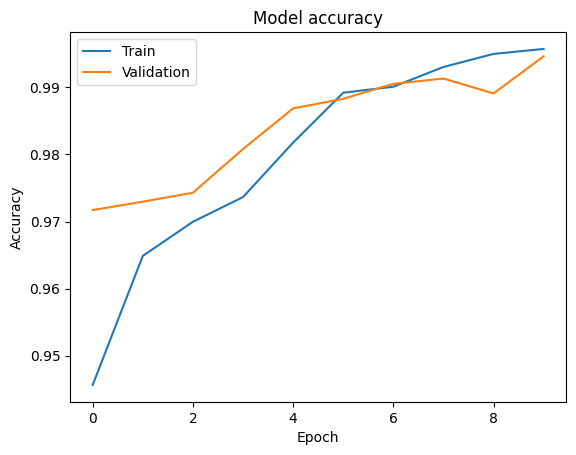

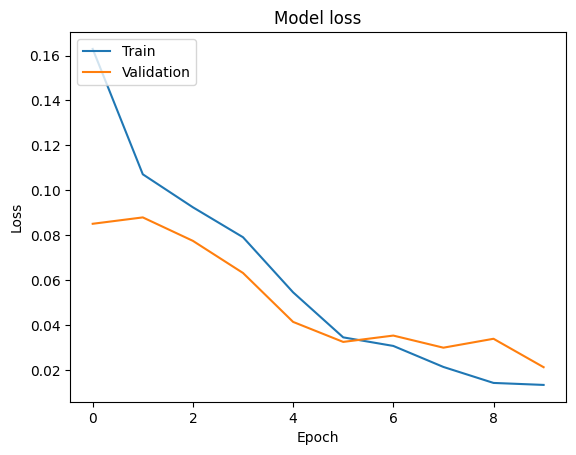

In [9]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history_dict['accuracy'])
plt.plot(history_dict['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history_dict['loss'])
plt.plot(history_dict['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## 7. Model Evaluation

Evaluated on the held-out test set. Precision, recall and F1 are macro-averaged.

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

class_names = list(test_generator.class_indices.keys())
y_pred = np.argmax(model.predict(test_generator), axis=1)
y_true = test_generator.classes

print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='macro'):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='macro'):.4f}")
print(f"F1-score : {f1_score(y_true, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

351/351 [==============================] - 53s 141ms/step
Accuracy : 0.9923
Precision: 0.9924
Recall   : 0.9924
F1-score : 0.9923

              precision    recall  f1-score   support

     Arborio     0.9872    0.9942    0.9907      2250
     Basmati     0.9859    0.9956    0.9907      2250
      Ipsala     0.9995    0.9991    0.9993      2206
     Jasmine     0.9928    0.9791    0.9859      2250
   Karacadag     0.9964    0.9938    0.9951      2250

    accuracy                         0.9923     11206
   macro avg     0.9924    0.9924    0.9923     11206
weighted avg     0.9923    0.9923    0.9923     11206



## 8. Model Prediction

1/1 [==============================] - 0s 61ms/step


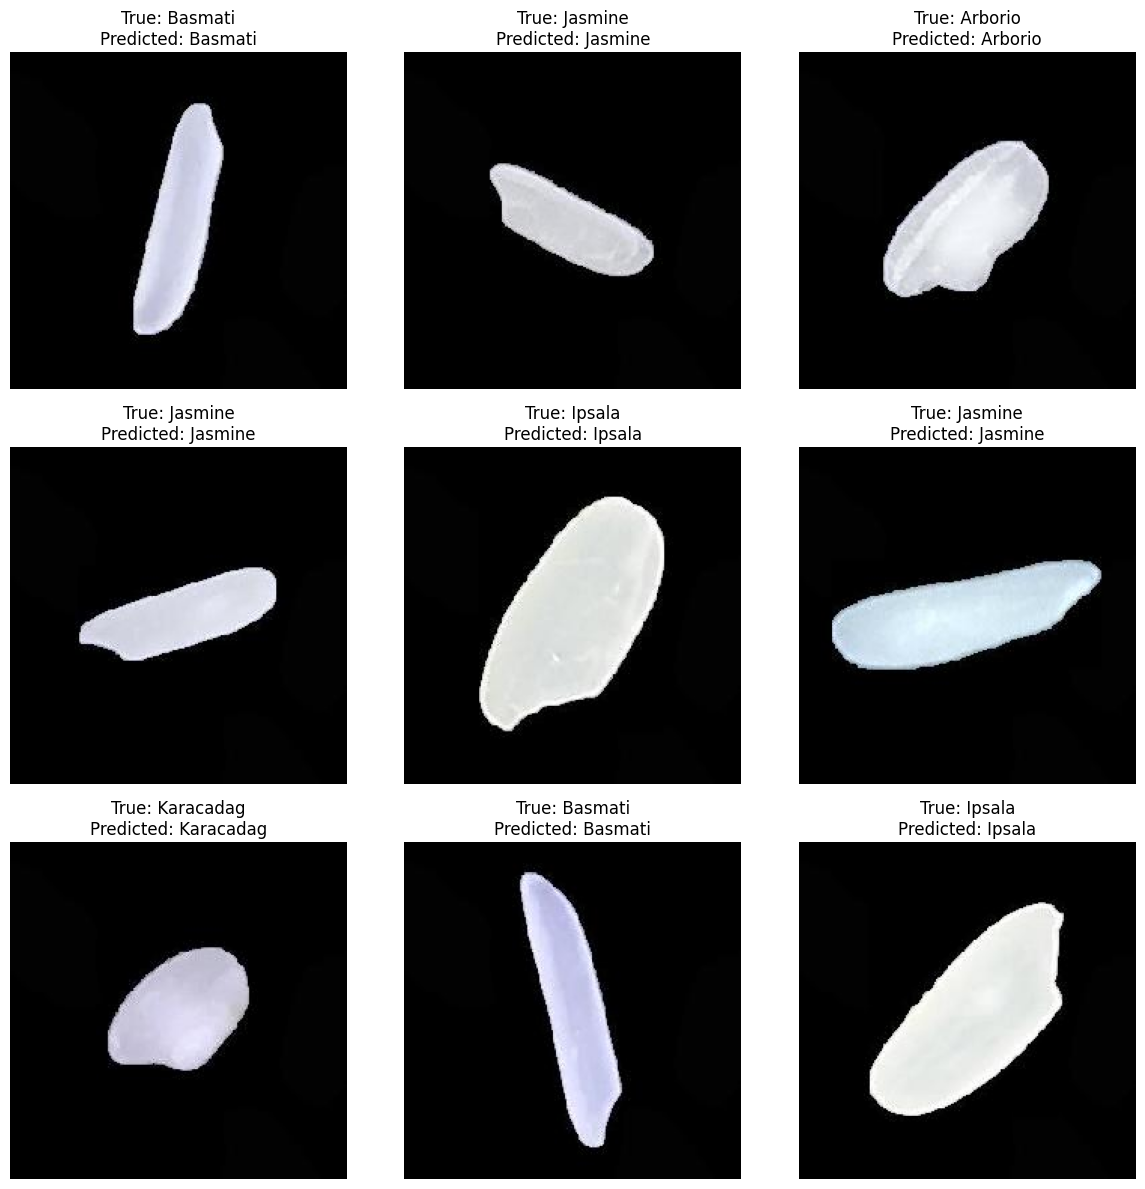

In [11]:
X_test, y_test = test_generator.next() 
predictions = model.predict(X_test)

def plot_predictions(X_test, y_test, predictions, class_indices):
    plt.figure(figsize=(12, 12))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X_test[i])
        true_label = np.argmax(y_test[i])
        predicted_label = np.argmax(predictions[i])
        true_class = list(class_indices.keys())[list(class_indices.values()).index(true_label)]
        predicted_class = list(class_indices.keys())[list(class_indices.values()).index(predicted_label)]
        plt.title(f"True: {true_class}\nPredicted: {predicted_class}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_predictions(X_test, y_test, predictions, test_generator.class_indices)